--- 1. Imports & Setup ---
✅ Libraries Imported Successfully

--- 2. Dataset Loading ---
⏳ Loading used_cars.csv...
✅ Dataset Loaded: 4009 rows, 12 columns
🎯 Target Variable: 'price'

--- 3. Cleaning & Feature Engineering ---
   Rows before filtering: 4009
   Rows after filtering outliers ($2k - $200k): 3934
✅ Data Cleaned & Features Engineered.

--- 4. Visualizing Data ---


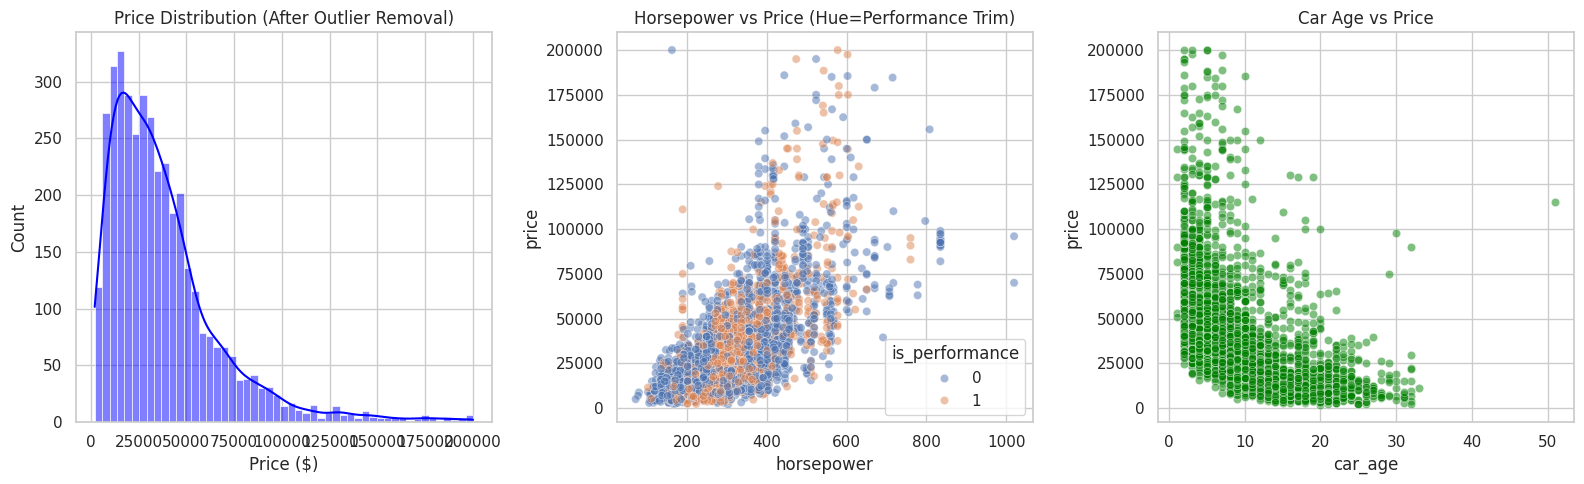


--- 5. Training Models ---

Model Comparison (3-Fold CV):
Model                | RMSE       | MAE       
----------------------------------------------
Linear Regression    | 18,427      | 11,472
Random Forest        | 14,811      | 8,511
Gradient Boosting    | 15,195      | 9,257
----------------------------------------------
🏆 Selected Model: Random Forest
📝 Reason: Lowest cross-validated RMSE (14,811) and balanced MAE.
✅ Model saved: corrected_car_price_model.joblib

--- 6. Explainability ---
Top 5 Price Drivers:
 1. num__milage (0.4371)
 3. num__horsepower (0.2266)
 2. num__car_age (0.0788)
 47. cat__brand_Porsche (0.0458)
 10. cat__brand_Bentley (0.0254)


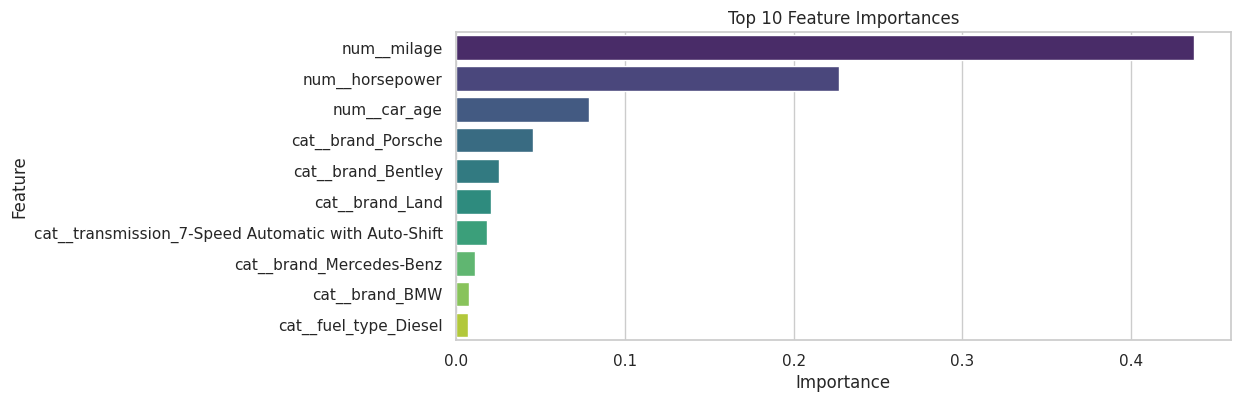


 🚗 CORRECTED PRICE PREDICTOR 

🔹 Select Brand:
  1) Audi
  2) BMW
  3) Cadillac
  4) Chevrolet
  5) Dodge
  6) Ford
  7) GMC
  8) Jeep
  9) Land
  10) Lexus
  11) Mercedes-Benz
  12) Nissan
  13) Porsche
  14) RAM
  15) Toyota
👉 Select (1-15): 12

🔹 Select Model (Top 20):
  1) 1500 Laramie
  2) 911 Carrera
  3) 911 Carrera S
  4) Camaro 2SS
  5) Corvette Base
  6) E-Class E 350
  7) E-Class E 350 4MATIC
  8) Explorer XLT
  9) F-150 Lariat
  10) F-150 XLT
  11) F-250 Lariat
  12) Land Cruiser Base
  13) M3 Base
  14) M4 Base
  15) M5 Base
  16) Macan S
  17) Model Y Long Range
  18) Mustang GT Premium
  19) R1S Adventure Package
  20) Wrangler Sport
  21) Other
👉 Select (1-21): 4

🔹 Select Fuel:
  1) Diesel
  2) E85 Flex Fuel
  3) Gasoline
  4) Hybrid
  5) Plug-In Hybrid
  6) not supported
  7) –
👉 Select (1-7): 6

🔹 Select Transmission:
  1) 1-Speed A/T
  2) 1-Speed Automatic
  3) 10-Speed A/T
  4) 10-Speed Automatic
  5) 10-Speed Automatic with Overdrive
  6) 2
  7) 2-Speed A/T
  8) 

In [8]:
# ==========================================
# END-TO-END CAR PRICE PREDICTION (FINAL + GRAPHS)
# ==========================================

# 1. IMPORTS
print("--- 1. Imports & Setup ---")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import warnings

# Sklearn
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
print("✅ Libraries Imported Successfully")

# ------------------------------------------------------------------------------
# 2. DATASET LOADING
# ------------------------------------------------------------------------------
print("\n--- 2. Dataset Loading ---")
filename = "used_cars.csv"
print(f"⏳ Loading {filename}...")

try:
    df = pd.read_csv(filename)
    print(f"✅ Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"🎯 Target Variable: 'price'")
except FileNotFoundError:
    print(f"❌ Error: '{filename}' not found. Please upload it first.")
    df = pd.DataFrame()

if not df.empty:
    # ------------------------------------------------------------------------------
    # 3. CLEANING & ADVANCED FEATURE ENGINEERING (FIXES APPLIED)
    # ------------------------------------------------------------------------------
    print("\n--- 3. Cleaning & Feature Engineering ---")

    # Helper Functions
    def clean_currency(x):
        if isinstance(x, str):
            clean_str = x.replace('$', '').replace(',', '')
            return float(clean_str) if clean_str else np.nan
        return x

    def clean_mileage(x):
        if isinstance(x, str):
            clean_str = x.replace('mi.', '').replace(',', '').strip()
            return float(clean_str) if clean_str else np.nan
        return x

    def extract_hp(x):
        if isinstance(x, str):
            match = re.search(r'(\d+\.?\d*)HP', x)
            if match:
                return float(match.group(1))
        return np.nan

    def check_performance_trim(row):
        """
        🚨 FIX #3: Extract 'Trim' Details
        Checks engine/model for performance keywords (Turbo, Sport, V8, AMG).
        """
        text = str(row['engine']) + " " + str(row['model'])
        keywords = ['turbo', 'sport', 'v8', 'v6', 'amg', 'm competition', 'gt', 'platinum', 'limited']
        if any(k in text.lower() for k in keywords):
            return 1
        return 0

    df_clean = df.copy()

    # Basic Cleaning
    df_clean['price'] = df_clean['price'].apply(clean_currency)
    df_clean['milage'] = df_clean['milage'].apply(clean_mileage)
    df_clean['horsepower'] = df_clean['engine'].apply(extract_hp)
    df_clean['car_age'] = 2025 - df_clean['model_year']

    # Categorical Defaults
    df_clean['accident'] = df_clean['accident'].fillna('None reported')
    df_clean['clean_title'] = df_clean['clean_title'].fillna('Unknown')

    # 🚨 FIX #2: Remove Outliers (The "Bugatti" Problem)
    # Filter cars between $2k and $200k to stabilize the graphs and model
    print(f"   Rows before filtering: {len(df_clean)}")
    df_clean = df_clean[(df_clean['price'] >= 2000) & (df_clean['price'] <= 200000)]
    print(f"   Rows after filtering outliers ($2k - $200k): {len(df_clean)}")

    # 🚨 FIX #3: Create 'Is_Performance' Feature
    df_clean['is_performance'] = df_clean.apply(check_performance_trim, axis=1)

    # 🚨 FIX #1: Handle 'Model' Column (Top 20 Strategy)
    # Keep Top 20 most frequent models, label others "Other"
    top_models = df_clean['model'].value_counts().head(20).index.tolist()
    df_clean['model_grouped'] = df_clean['model'].apply(lambda x: x if x in top_models else 'Other')

    # Drop raw text columns
    cols_to_drop = ['model', 'model_year', 'engine', 'ext_col', 'int_col']
    df_final = df_clean.drop(columns=cols_to_drop, errors='ignore')
    df_final = df_final.dropna(subset=['price'])

    print("✅ Data Cleaned & Features Engineered.")

    # ------------------------------------------------------------------------------
    # 4. VISUALIZATION (GRAPHS RESTORED)
    # ------------------------------------------------------------------------------
    print("\n--- 4. Visualizing Data ---")
    plt.figure(figsize=(16, 5))

    # Plot 1: Price Distribution (Cleaned)
    plt.subplot(1, 3, 1)
    sns.histplot(df_final['price'], kde=True, color='blue')
    plt.title('Price Distribution (After Outlier Removal)')
    plt.xlabel('Price ($)')

    # Plot 2: Horsepower vs Price
    plt.subplot(1, 3, 2)
    sns.scatterplot(x='horsepower', y='price', data=df_final, alpha=0.5, hue='is_performance')
    plt.title('Horsepower vs Price (Hue=Performance Trim)')

    # Plot 3: Car Age vs Price
    plt.subplot(1, 3, 3)
    sns.scatterplot(x='car_age', y='price', data=df_final, alpha=0.5, color='green')
    plt.title('Car Age vs Price')

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------------------
    # 5. PREPROCESSING & TRAINING
    # ------------------------------------------------------------------------------
    print("\n--- 5. Training Models ---")

    X = df_final.drop(columns=['price'])
    y = df_final['price']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Note: 'model_grouped' is included
    num_cols = ['milage', 'car_age', 'horsepower', 'is_performance']
    cat_cols = ['brand', 'model_grouped', 'fuel_type', 'transmission', 'accident', 'clean_title']

    preprocessor = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ])

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42)
    }

    results_data = []
    best_name = ""
    best_score = float('inf')

    print("\nModel Comparison (3-Fold CV):")
    print(f"{'Model':<20} | {'RMSE':<10} | {'MAE':<10}")
    print("-" * 46)

    for name, model in models.items():
        pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])

        cv_results = cross_validate(pipe, X_train, y_train, cv=3,
                                    scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'])

        rmse = np.sqrt(-cv_results['test_neg_mean_squared_error'].mean())
        mae = -cv_results['test_neg_mean_absolute_error'].mean()

        print(f"{name:<20} | {rmse:,.0f}      | {mae:,.0f}")

        if rmse < best_score:
            best_score = rmse
            best_name = name

    print("-" * 46)
    print(f"🏆 Selected Model: {best_name}")
    print(f"📝 Reason: Lowest cross-validated RMSE ({best_score:,.0f}) and balanced MAE.")

    # Final Training
    final_pipeline = Pipeline([('preprocessor', preprocessor), ('model', models[best_name])])
    final_pipeline.fit(X_train, y_train)

    joblib.dump(final_pipeline, 'corrected_car_price_model.joblib')
    print("✅ Model saved: corrected_car_price_model.joblib")

    # ------------------------------------------------------------------------------
    # 6. EXPLAINABILITY
    # ------------------------------------------------------------------------------
    print("\n--- 6. Explainability ---")
    if hasattr(models[best_name], 'feature_importances_'):
        try:
            feat_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
            imps = final_pipeline.named_steps['model'].feature_importances_
            fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': imps}).sort_values('Importance', ascending=False)

            print("Top 5 Price Drivers:")
            for i, row in fi_df.head(5).iterrows():
                print(f" {i+1}. {row['Feature']} ({row['Importance']:.4f})")

            # Feature Importance Graph
            plt.figure(figsize=(10, 4))
            sns.barplot(x='Importance', y='Feature', data=fi_df.head(10), palette='viridis')
            plt.title('Top 10 Feature Importances')
            plt.show()
        except: pass

    # ------------------------------------------------------------------------------
    # 7. INTERACTIVE MENU
    # ------------------------------------------------------------------------------
    def get_choice(prompt, options):
        print(f"\n🔹 {prompt}:")
        for i, opt in enumerate(options, 1):
            print(f"  {i}) {opt}")
        while True:
            try:
                c = int(input(f"👉 Select (1-{len(options)}): "))
                if 1 <= c <= len(options): return options[c-1]
            except ValueError: pass
            print("❌ Invalid.")

    def run_menu_predictor():
        print("\n" + "="*40 + "\n 🚗 CORRECTED PRICE PREDICTOR \n" + "="*40)

        # Lists
        brands = sorted(df_final['brand'].value_counts().head(15).index.tolist())
        # FIX #1 IN MENU: Allow user to choose from popular models or 'Other'
        models_list = sorted(top_models) + ["Other"]
        fuels = sorted(df_final['fuel_type'].dropna().unique().tolist())
        trans = sorted(df_final['transmission'].dropna().unique().tolist())

        # Inputs
        u_brand = get_choice("Select Brand", brands)
        u_model = get_choice("Select Model (Top 20)", models_list)
        u_fuel = get_choice("Select Fuel", fuels)
        u_trans = get_choice("Select Transmission", trans)

        print("\n🔹 Enter Numeric Details:")
        while True:
            try:
                u_year = int(input("  👉 Year (e.g., 2019): "))
                u_mil = float(input("  👉 Mileage (e.g., 50000): "))
                u_hp = float(input("  👉 Horsepower (e.g., 200): "))
                break
            except: print("❌ Enter numbers only.")

        # Infer Performance (Fix #3 for input)
        print("\n🔹 Is this a Performance/Sport/Turbo trim?")
        u_perf_input = input("  👉 (y/n): ").lower()
        u_perf = 1 if u_perf_input == 'y' else 0

        # Summary
        print("\n" + "-"*30)
        print("📋 Input Summary:")
        print(f"   • {u_year} {u_brand} {u_model}")
        print(f"   • Performance Trim: {'Yes' if u_perf else 'No'}")
        print(f"   • Mileage: {u_mil:,.0f} | HP: {u_hp}")
        print("-"*30)

        # Predict
        data = pd.DataFrame({
            'brand': [u_brand],
            'model_grouped': [u_model],
            'milage': [u_mil],
            'car_age': [2025-u_year],
            'horsepower': [u_hp],
            'is_performance': [u_perf],
            'fuel_type': [u_fuel],
            'transmission': [u_trans],
            'accident': ["None reported"],
            'clean_title': ["Unknown"]
        })

        pred = final_pipeline.predict(data)[0]
        print(f"\n💰 ESTIMATED PRICE: ${pred:,.2f}")
        print("="*40)

    run_menu_predictor()